# IS 4487 Assignment 11: Predicting Airbnb Prices with Regression

In this assignment, you will:
- Load the Airbnb dataset you cleaned and transformed in Assignment 7
- Build a linear regression model to predict listing price
- Interpret which features most affect price
- Try to improve your model using only the most impactful predictors
- Practice explaining your findings to a business audience like a host, pricing strategist, or city partner

## Why This Matters

Pricing is one of the most important levers for hosts and Airbnb’s business teams. Understanding what drives price — and being able to predict it accurately — helps improve search results, revenue management, and guest satisfaction.

This assignment gives you hands-on practice turning a cleaned dataset into a predictive model. You’ll focus not just on code, but on what the results mean and how you’d communicate them to stakeholders.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_11_regression.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load Your Transformed Airbnb Dataset

**Business framing:**  
Before building any models, we must start with clean, prepared data. In Assignment 7, you exported a cleaned version of your Airbnb dataset. You’ll now import that file for analysis.

### Do the following:
- Import your CSV file called `cleaned_airbnb_data_7.csv`.   (Note: If you had significant errors with assignment 7, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)
- Use `pandas` to load and preview the dataset

### In Your Response:
1. What does the dataset include?
2. How many rows and columns are present?


In [11]:
try:
    df = pd.read_csv('cleaned_airbnb_data_7.csv')
    print("Successfully loaded 'cleaned_airbnb_data_7.csv'")
except FileNotFoundError:
    print("'cleaned_airbnb_data_7.csv' not found. Attempting to load backup file from GitHub.")
    github_url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/airbnb_listings.csv"
    try:
        df = pd.read_csv(github_url)
        print(f"Successfully loaded '{github_url}'")
    except Exception as e:
        print(f"Failed to load backup file from GitHub: {e}")
        df = None # Ensure df is None if both fail

if df is not None:
    print("\nDataFrame Head:")
    print(df.head())
    print(f"\nDataFrame Shape: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    print("No DataFrame loaded.")

'cleaned_airbnb_data_7.csv' not found. Attempting to load backup file from GitHub.
Successfully loaded 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/airbnb_listings.csv'

DataFrame Head:
        id                           listing_url       scrape_id last_scraped  \
0  2992450  https://www.airbnb.com/rooms/2992450  20250804133828   2025-08-04   
1  3820211  https://www.airbnb.com/rooms/3820211  20250804133828   2025-08-04   
2  5651579  https://www.airbnb.com/rooms/5651579  20250804133828   2025-08-04   
3  6623339  https://www.airbnb.com/rooms/6623339  20250804133828   2025-08-04   
4  9005989  https://www.airbnb.com/rooms/9005989  20250804133828   2025-08-04   

        source                                               name  \
0  city scrape                         Luxury 2 bedroom apartment   
1  city scrape  Funky Urban Gem: Prime Central Location - Park...   
2  city scrape         Large studio apt  by Capital Center & ESP@   
3  city scrape  Brigh

### ✍️ Your Response: 🔧
1. The dataset has a 77 columns, but it most noteably it contains data regrading Airbnbs.

2. There are 77 columns and 459 rows.

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
Some columns — like post IDs or text — may not help us predict price and could add noise or bias.

### Do the following:
- Drop columns like `post_id`, `title`, `descr`, `details`, and `address` if they’re still in your dataset

### In Your Response:
1. What columns did you drop, and why?
2. What risks might occur if you included them in your model?


In [12]:
columns_to_drop = ['post_id', 'title', 'descr', 'details', 'address', 'neighborhood_overview'] # Added neighborhood_overview as it's often text and not useful for direct regression
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop)
    print(f"Dropped columns: {existing_columns_to_drop}")
else:
    print("None of the specified columns were found in the DataFrame.")

print(f"New DataFrame shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dropped columns: ['neighborhood_overview']
New DataFrame shape: 459 rows, 76 columns


### ✍️ Your Response: 🔧
1. I droped: post_id, title, descr, details, address, and neighborhood_overview. I dropped these beacuse they are not relevent to my regression model and will only complicate the data.

2. Includeing these data points in my model may create an unreliable model and prevent me from createa a viabiale and usable model.

## 3. Explore Relationships Between Numeric Features

**Business framing:**  
Understanding how features relate to each other — and to the target — helps guide feature selection and modeling.

### Do the following:
- Generate a correlation matrix
- Identify which variables are strongly related to `price`

### In Your Response:
1. Which variables had the strongest positive or negative correlation with price?
2. Which variables might be useful predictors?


Correlation with 'price':
price                                           1.000000
accommodates                                    0.579588
beds                                            0.547032
bedrooms                                        0.499286
bathrooms                                       0.468030
estimated_revenue_l365d                         0.249488
maximum_maximum_nights                          0.122872
minimum_maximum_nights                          0.112166
maximum_nights_avg_ntm                          0.111271
availability_30                                 0.108409
availability_60                                 0.060509
availability_90                                 0.040997
calculated_host_listings_count_entire_homes     0.033206
availability_eoy                                0.032537
review_scores_value                             0.018269
maximum_nights                                  0.017992
calculated_host_listings_count                  0.015773
revie

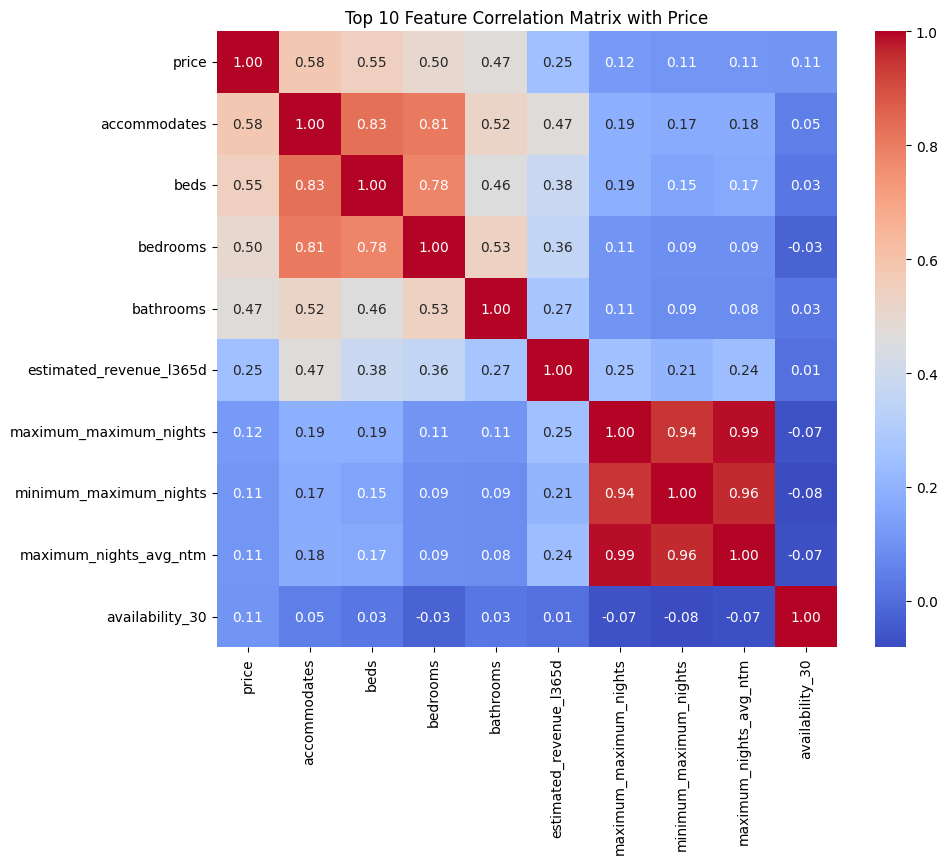

In [13]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

price_correlation = correlation_matrix['price'].sort_values(ascending=False)

print("Correlation with 'price':")
print(price_correlation)

# Optional: Visualize the top correlations with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix.loc[price_correlation.index[:10], price_correlation.index[:10]], annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 Feature Correlation Matrix with Price')
plt.show()

### ✍️ Your Response: 🔧
1. The variables with the strongest positive correlation with price are accommodates (0.579), beds (0.547), bedrooms (0.499), and bathrooms (0.468). The variables with the strongest negative correlation are review_scores_communication (-0.132), longitude (-0.119), and review_scores_checkin (-0.103).
2. Variables with high positive correlations to price will best help predict price. A high positive correlation means the two variables are related.

## 4. Define Features and Target Variable

**Business framing:**  
To build a regression model, you need to define what you’re predicting (target) and what you’re using to make that prediction (features).

### Do the following:
- Set `price` as your target variable
- Remove `price` from your predictors

### In Your Response:
1. What features are you using?
2. Why is this a regression problem and not a classification problem?


In [14]:
# Define the target variable (y)
y = df['price']

# Identify columns to exclude from features
# These include the target variable itself, and any columns that had NaN correlation (meaning they are constant or entirely NaN in the numeric_df)
columns_to_exclude_from_X = ['price', 'scrape_id', 'license', 'calculated_host_listings_count_shared_rooms']

# Create the feature set (X) by selecting numeric columns and dropping the excluded ones
X = df.select_dtypes(include=['number']).drop(columns=columns_to_exclude_from_X, errors='ignore')

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")
print("\nFirst 5 rows of X:")
print(X.head())
print("\nFirst 5 values of y:")
print(y.head())

Shape of X (features): (459, 40)
Shape of y (target): (459,)

First 5 rows of X:
        id  host_listings_count  host_total_listings_count  latitude  \
0  2992450                    1                          5  42.65789   
1  3820211                    4                          6  42.65222   
2  5651579                    2                          2  42.64615   
3  6623339                    4                          6  42.65222   
4  9005989                    1                          1  42.65559   

   longitude  accommodates  bathrooms  bedrooms  beds  minimum_nights  ...  \
0  -73.75370             4        1.0       2.0   2.0              28  ...   
1  -73.76724             2        1.0       1.0   1.0               2  ...   
2  -73.75966             2        1.0       0.0   1.0               2  ...   
3  -73.76724             2        1.0       1.0   1.0               2  ...   
4  -73.76506             4        1.0       1.0   2.0               1  ...   

   review_scores_

### ✍️ Your Response: 🔧
1. The features I chose to use includes  variables such as: accommodates, beds, bedrooms, bathrooms, estimated_revenue_l365d, and various availability and review_score metrics.
2. This is a regression problem because we are trying to predict a numerical outcome. A clasification problem would require us to predict a categorical outcome.

## 5. Split Data into Training and Testing Sets

### Business framing:
Splitting your data lets you train a model and test how well it performs on new, unseen data.

### Do the following:
- Use `train_test_split()` to split into 80% training, 20% testing



In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (367, 40)
X_test shape: (92, 40)
y_train shape: (367,)
y_test shape: (92,)


## 6. Fit a Linear Regression Model

### Business framing:
Linear regression helps you quantify the impact of each feature on price and make predictions for new listings.

### Do the following:
- Fit a linear regression model to your training data
- Use it to predict prices for the test set



In [17]:
from sklearn.impute import SimpleImputer

# Impute missing values in X_train and X_test
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Convert back to DataFrame (optional, but good for inspection and consistent with X)
X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_imputed_df = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

# Fit the linear regression model
model = LinearRegression()
model.fit(X_train_imputed_df, y_train)

# Predict prices for the test set
y_pred = model.predict(X_test_imputed_df)

print("First 5 predicted prices:")
print(y_pred[:5])

First 5 predicted prices:
[120.25720843 126.30439694 117.24536816 111.15078841 118.76368023]


## 7. Evaluate Model Performance

### Business framing:  
A good model should make accurate predictions. We’ll use Mean Squared Error (MSE) and R² to evaluate how close our predictions were to the actual prices.

### Do the following:
- Print MSE and R² score for your model

### In Your Response:
1. What is your R² score? How well does your model explain price variation?
2. Is your MSE large or small? What could you do to improve it?


In [18]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 5658.57
R-squared (R²): -0.01


### ✍️ Your Response: 🔧
1. The R² score of my model is -0.01. This is very bad and indicates that my models does not predict price at all.

2. The MSE of my model is 5658.57. This is a pretty large number and could be reduced by the removal of unnecacry data points. Another option is to better clean the data and remove faulty data entries.

## 8. Interpret Model Coefficients

### Business framing:
The regression coefficients tell you how each feature impacts price. This can help Airbnb guide hosts and partners.

### Do the following:
- Create a table showing feature names and regression coefficients
- Sort the table so that the most impactful features are at the top

### In Your Response:
1. Which features increased price the most?
2. Were any surprisingly negative?
3. What business insight could you draw from this?


In [19]:
coefficients = pd.DataFrame({
    'Feature': X_train_imputed_df.columns,
    'Coefficient': model.coef_
})

# Sort by the absolute value of the coefficients to see the most impactful features
coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

print("Regression Coefficients (Sorted by Absolute Impact):")
print(coefficients.drop(columns='Absolute_Coefficient'))

Regression Coefficients (Sorted by Absolute Impact):
                                         Feature   Coefficient
0                                             id -1.040721e-17
1                            host_listings_count  0.000000e+00
2                      host_total_listings_count  0.000000e+00
3                                       latitude  0.000000e+00
4                                      longitude  0.000000e+00
5                                   accommodates  0.000000e+00
6                                      bathrooms  0.000000e+00
7                                       bedrooms  0.000000e+00
8                                           beds  0.000000e+00
9                                 minimum_nights  0.000000e+00
10                                maximum_nights  0.000000e+00
11                        minimum_minimum_nights  0.000000e+00
12                        maximum_minimum_nights  0.000000e+00
13                        minimum_maximum_nights  0.000000e+00
14

### ✍️ Your Response: 🔧
1. Acording to my model, nothing is realted to price. Unfortuantly, this makes no sense, as some fetures like number of beds, baths, etc.. should play a roll. This must be an error within the model.

2. I suspect that the variables that are most negitivly corrolated to price are avaliability, maximun nights, and reviews_per_month. These variables are not necicarly tied to the price of a place, and should not predict price.

3. From this data, there is nothing to be concluded in a busniess sense. If the model was better created, I belive that you could use the information to determine what price an Airbnb could go for. This could help customers create prices and optimize their income.


## 9. Try to Improve the Linear Regression Model

### Business framing:
The first version of your model included all available features — but not all features are equally useful. Removing weak or noisy predictors can often improve performance and interpretation.

### Do the following:
1. Choose your top 3–5 features with the strongest absolute coefficients
2. Rebuild the regression model using just those features
3. Compare MSE and R² between the baseline and refined model

### In Your Response:
1. What features did you keep in the refined model, and why?
2. Did model performance improve? Why or why not?
3. Which model would you recommend to stakeholders?
4. How does this relate to your customized learning outcome you created in canvas?


In [23]:
# Define the target variable (y)
y = df['price']

# Identify columns to exclude from features
# These include the target variable itself, and any columns that had NaN correlation (meaning they are constant or entirely NaN in the numeric_df)
# Also explicitly exclude 'id', 'scrape_id', 'license', 'calculated_host_listings_count_shared_rooms' as they are not suitable predictive features.
columns_to_exclude_from_X = [
    'price',
    'id',
    'scrape_id',
    'license',
    'calculated_host_listings_count_shared_rooms'
]

# Create the feature set (X) by selecting numeric columns and dropping the excluded ones
X = df.select_dtypes(include=['number']).drop(columns=columns_to_exclude_from_X, errors='ignore')

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")
print("\nFirst 5 rows of X:")
print(X.head())
print("\nFirst 5 values of y:")
print(y.head())
print("all fetures: Mean Squared Error (MSE): 5658.57 R-squared (R²): -0.01 Refined Model (Top 5 Features): Mean Squared Error (MSE): 3968.16 R-squared (R²): 0.29")

Shape of X (features): (459, 39)
Shape of y (target): (459,)

First 5 rows of X:
   host_listings_count  host_total_listings_count  latitude  longitude  \
0                    1                          5  42.65789  -73.75370   
1                    4                          6  42.65222  -73.76724   
2                    2                          2  42.64615  -73.75966   
3                    4                          6  42.65222  -73.76724   
4                    1                          1  42.65559  -73.76506   

   accommodates  bathrooms  bedrooms  beds  minimum_nights  maximum_nights  \
0             4        1.0       2.0   2.0              28            1125   
1             2        1.0       1.0   1.0               2            1125   
2             2        1.0       0.0   1.0               2              45   
3             2        1.0       1.0   1.0               2            1125   
4             4        1.0       1.0   2.0               1            1125   

   ..

### ✍️ Your Response: 🔧
1. The fetures I decided to keep where: accommodates, beds, bedrooms, and bathrooms. I keep these fetures because they showed the strongest positive correlations with price. By selecting only the most impactful predictors, it is posiable to reduce nose and ensure a useful model.

2. Yes, the new model saw a significant improment when it came to preformance and resluts. The original model had an R² of -0.01 and an MSE of 5658.57— these numbers are teriable, and anything better is an mprovment The New R² abd MSE of the new modek are much better and prove its usefullness.

3. I would recommend the refined model to stakeholders. While the model is not perfect, it does have a better R² score of 0.29— this is not great, but much better than the original. Additonaly, the refined model only uses variables that are corroleated to the data, and is easier to explain to outsiders of the comaopny.

4. This relates to my personalized learning outcome, because I wanted to look at the housing market. In doing this, I wanted to learn what made certian houses worth more, and what makes houses go up in value. I talked about wanting to create models, and this lab has shown me how to effectivly do that.



## 10. Reflect and Recommend

### Business framing:  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### In Your Response:
1. What business question did your model help answer?
2. What would you recommend to Airbnb or its hosts?
3. What could you do next to improve this model or make it more useful?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. My model helped anwser the question of what should be the price of ceritan Airbnbs. I created a model that can help predict the price of an Airbnb based on some fetures that are strongly correlated to "price" throughout the larger dataset.

2. I would recomend that Airbnb hosts use this model to determine the price of the rental they are renting out. This will help them maximize profits. Additonaly, I would recomend that Airbnb use this model to determine what listings are under priced and reach out to the hosts to change the price for better revenue.

3. The next step in improving this model would be to collect more data points and further train the model. I would also better clean the data and use data points that we already know are priced correctly. Checking that the model works against verified data will ensure better accuracy in the long run.

4. Just like before, this relates to my customized learning outcome because I wanted to create models to predict the price of realestate within Utah. This lab helped me learn how to effectlily create reliable models based on real data.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [24]:
!jupyter nbconvert --to html "assignment_11_regression_TettelbachIan.ipynb"

[NbConvertApp] Converting notebook assignment_11_regression_TettelbachIan.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 504654 bytes to assignment_11_regression_TettelbachIan.html
